# Fake News Detection

## 1. Dataset Download

Dataset: ISOT Fake and Real News Dataset, retrieved via `kagglehub`.

Requires: `pip install kagglehub`


In [1]:
!pip uninstall -y torchvision

In [2]:
import kagglehub
import shutil
import os

dataset_path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

for file in ["Fake.csv", "True.csv"]:
    if not os.path.exists(file):
        shutil.copy(os.path.join(dataset_path, file), file)

FAKE_PATH = "Fake.csv"
TRUE_PATH = "True.csv"

## 2. Load and Label Data

The dataset consists of two files, `Fake.csv` and `True.csv`, each containing `title`, `text`, `subject`, and `date` columns. A `label` column is added to distinguish the two classes before combining.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)

fake_df["label"] = "fake"
true_df["label"] = "real"

print("Fake shape:", fake_df.shape)
print("True shape:", true_df.shape)

fake_df.head()


Fake shape: (23481, 5)
True shape: (21417, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


## 3. Combine Dataset

In [4]:
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("Combined shape:", df.shape)
df.info()
df.head()


Combined shape: (44898, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",fake
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",real
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",real
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",fake
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",real


## 4. Class Balance

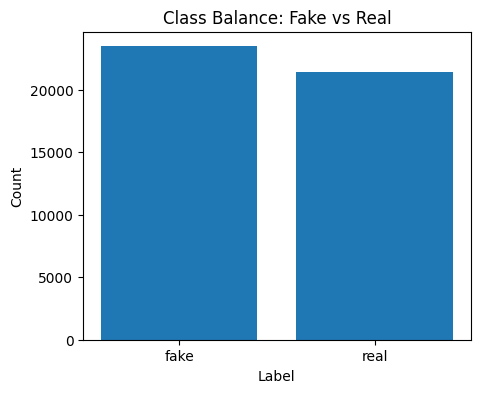

In [5]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(counts.index, counts.values)
plt.title("Class Balance: Fake vs Real")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 5. Article Length Distribution

Word count distributions for titles and article bodies. Relevant for the max sequence length parameter used when fine-tuning DistilBERT/RoBERTa.


In [6]:
df["title_word_count"] = df["title"].str.split().str.len()
df["text_word_count"] = df["text"].str.split().str.len()

print(df[["title_word_count", "text_word_count"]].describe())

print(f"Articles over 256 words: {(df['text_word_count'] > 256).mean():.1%}")

print(f"Articles over 512 words: {(df['text_word_count'] > 512).mean():.1%}")

       title_word_count  text_word_count
count      44898.000000     44898.000000
mean          12.453472       405.282284
std            4.111476       351.265595
min            1.000000         0.000000
25%           10.000000       203.000000
50%           11.000000       362.000000
75%           14.000000       513.000000
max           42.000000      8135.000000
Articles over 256 words: 68.6%
Articles over 512 words: 25.0%


## 6. Subject/Topic Distribution

label            fake   real
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145


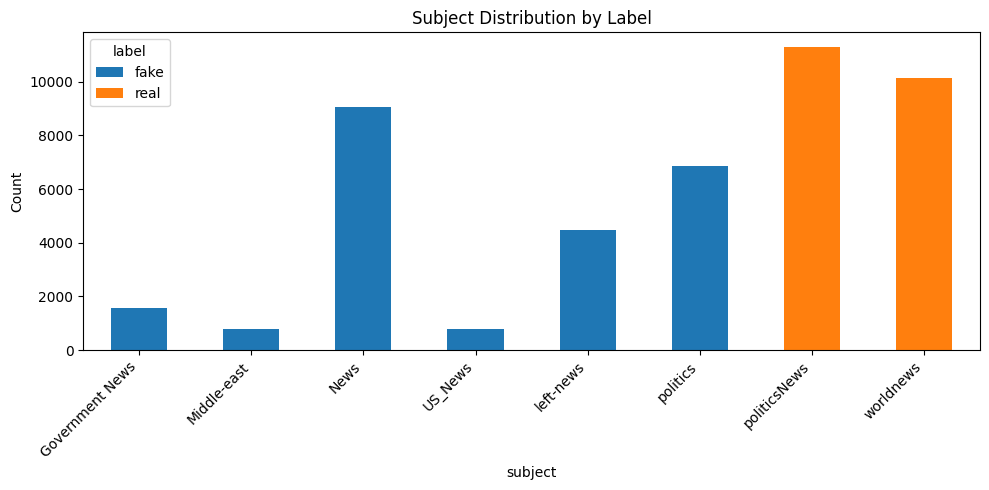

In [7]:
if "subject" in df.columns:
    subject_counts = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
    print(subject_counts)

    subject_counts.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title("Subject Distribution by Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'subject' column found in this dataset version.")


## 7. Missing Values and Duplicates

In [8]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate articles: {df.duplicated(subset=['text']).sum()}")

print(f"Near-empty articles: {(df['text'].str.len() < 10).sum()}")

Missing values:
title               0
text                0
subject             0
date                0
label               0
title_word_count    0
text_word_count     0
dtype: int64



Duplicate rows: 209
Duplicate articles: 6252
Near-empty articles: 652


## 8. Data Cleaning and Split

Removes empty/near-empty text rows and duplicates, then creates a stratified train/validation/test split used consistently across all models (TF-IDF baseline, DistilBERT, RoBERTa).


In [9]:
from sklearn.model_selection import train_test_split

# Remove empty and duplicate articles
clean_df = df[df["text"].str.len() >= 10].drop_duplicates(subset=["text"]).copy()

# Encode labels
clean_df["label_id"] = clean_df["label"].map({"real": 0, "fake": 1})

# Split into train (70%), validation (15%), and test (15%)
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.3,
    stratify=clean_df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42
)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (27044, 8)
Validation: (5795, 8)
Test: (5796, 8)


## 10. Save Processed Splits

In [10]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Saved train.csv, val.csv, test.csv")


Saved train.csv, val.csv, test.csv


## 11. Baseline Model: TF-IDF + Logistic Regression

Baseline pipeline combining TF-IDF vectorization with Logistic Regression as a single model. TF-IDF converts article text into weighted term-frequency features; Logistic Regression is trained on those features to classify real vs fake. 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import time

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=2
    )),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Train
start = time.time()
baseline.fit(train_df["text"], train_df["label_id"])
train_time = time.time() - start

# Validation
start = time.time()
val_pred = baseline.predict(val_df["text"])
infer_time = time.time() - start

val_acc = accuracy_score(val_df["label_id"], val_pred)
val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
    val_df["label_id"], val_pred, average="binary"
)

print(f"Training time: {train_time:.2f}s")
print(f"Validation inference time: {infer_time:.4f}s")
print(f"Validation Accuracy: {val_acc:.4f}")
print(classification_report(val_df["label_id"], val_pred,
                            target_names=["real", "fake"]))

# Test
test_pred = baseline.predict(test_df["text"])
test_acc = accuracy_score(test_df["label_id"], test_pred)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    test_df["label_id"], test_pred, average="binary"
)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(test_df["label_id"], test_pred,
                            target_names=["real", "fake"]))

# Save results
baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "val_accuracy": val_acc,
    "val_precision": val_prec,
    "val_recall": val_rec,
    "val_f1": val_f1,
    "test_accuracy": test_acc,
    "test_precision": test_prec,
    "test_recall": test_rec,
    "test_f1": test_f1,
    "train_time_sec": train_time,
    "inference_time_sec": infer_time,
}
baseline_results

Training time: 25.18s
Validation inference time: 2.3496s
Validation Accuracy: 0.9865
              precision    recall  f1-score   support

        real       0.98      0.99      0.99      3179
        fake       0.99      0.98      0.98      2616

    accuracy                           0.99      5795
   macro avg       0.99      0.99      0.99      5795
weighted avg       0.99      0.99      0.99      5795




Test Accuracy: 0.9860
              precision    recall  f1-score   support

        real       0.98      0.99      0.99      3179
        fake       0.99      0.98      0.98      2617

    accuracy                           0.99      5796
   macro avg       0.99      0.99      0.99      5796
weighted avg       0.99      0.99      0.99      5796



{'model': 'TF-IDF + Logistic Regression',
 'val_accuracy': 0.9865401207937877,
 'val_precision': 0.9914794732765299,
 'val_recall': 0.9785932721712538,
 'val_f1': 0.9849942285494421,
 'test_accuracy': 0.9860248447204969,
 'test_precision': 0.9907120743034056,
 'test_recall': 0.9782193351165457,
 'test_f1': 0.9844260719092482,
 'train_time_sec': 25.181056022644043,
 'inference_time_sec': 2.3496365547180176}

## 13. Save Baseline Model

Saved for later use as the baseline comparison point and for the TF-IDF SHAP explainability step (`LinearExplainer`).


In [12]:
import joblib
import json

joblib.dump(baseline, "baseline.joblib")

with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved: baseline.joblib, baseline_results.json")

Saved: baseline.joblib, baseline_results.json


## 14. DistilBERT Fine-Tuning

Fine-tuning `distilbert-base-uncased` for binary classification (real vs fake), evaluated against the TF-IDF + Logistic Regression baseline using the same metrics (accuracy, precision, recall, F1) plus training and inference time.

Requires: `pip install transformers datasets torch scikit-learn`


In [13]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


### 14.1 Prepare Datasets

Converts the train/val/test dataframes into Hugging Face `Dataset` objects and tokenizes the article text.


In [14]:
from datasets import Dataset

MAX_LENGTH = 256
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_ds = Dataset.from_pandas(train_df[["text", "label_id"]]).rename_column("label_id", "labels")
val_ds = Dataset.from_pandas(val_df[["text", "label_id"]]).rename_column("label_id", "labels")
test_ds = Dataset.from_pandas(test_df[["text", "label_id"]]).rename_column("label_id", "labels")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(train_ds)

Map:   0%|          | 0/27044 [00:00<?, ? examples/s]

Map:   0%|          | 0/5795 [00:00<?, ? examples/s]

Map:   0%|          | 0/5796 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 27044
})


### 14.2 Model and Training Setup


In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import EarlyStoppingCallback

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

training_args = TrainingArguments(
    output_dir="./distilbert_fake_news",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


### 14.3 Train


In [16]:
import time

start_train = time.time()
trainer.train()
distilbert_train_time = time.time() - start_train

print(f"Training time: {distilbert_train_time:.2f}s")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.000126,0.008721,0.997757,0.999616,0.995413,0.997510
2,0.000022,0.001983,0.999827,1.000000,0.999618,0.999809
3,0.000012,0.002062,0.999655,0.999618,0.999618,0.999618
4,0.000007,0.002043,0.999827,1.000000,0.999618,0.999809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 1667.79s


### 14.4 Evaluate on Test Set


In [17]:
start_infer = time.time()
test_output = trainer.predict(test_ds)
distilbert_infer_time = time.time() - start_infer

test_preds = test_output.predictions.argmax(axis=-1)
test_labels = test_output.label_ids

test_acc = accuracy_score(test_labels, test_preds)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="binary"
)

print(f"Inference time (test set): {distilbert_infer_time:.2f}s")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}, Recall: {test_rec:.4f}, F1: {test_f1:.4f}")

from sklearn.metrics import classification_report
print()
print(classification_report(test_labels, test_preds, target_names=["real", "fake"]))


Inference time (test set): 29.92s
Test Accuracy: 0.9998
Test Precision: 1.0000, Recall: 0.9996, F1: 0.9998

              precision    recall  f1-score   support

        real       1.00      1.00      1.00      3179
        fake       1.00      1.00      1.00      2617

    accuracy                           1.00      5796
   macro avg       1.00      1.00      1.00      5796
weighted avg       1.00      1.00      1.00      5796



### 14.5 Compare Against Baseline


In [18]:
distilbert_results = {
    "model": "DistilBERT",
    "test_accuracy": test_acc,
    "test_precision": test_prec,
    "test_recall": test_rec,
    "test_f1": test_f1,
    "train_time_sec": distilbert_train_time,
    "inference_time_sec": distilbert_infer_time,
}

model_comparison = pd.DataFrame([
    {
        "model": baseline_results["model"],
        "test_accuracy": baseline_results["test_accuracy"],
        "test_precision": baseline_results["test_precision"],
        "test_recall": baseline_results["test_recall"],
        "test_f1": baseline_results["test_f1"],
        "train_time_sec": baseline_results["train_time_sec"],
        "inference_time_sec": baseline_results["inference_time_sec"],
    },
    distilbert_results
])

model_comparison


,model,test_accuracy,test_precision,test_recall,test_f1,train_time_sec,inference_time_sec
0,TF-IDF + Logistic Regression,0.986025,0.990712,0.978219,0.984426,25.181056,2.349637
1,DistilBERT,0.999827,1.000000,0.999618,0.999809,1667.788106,29.921970


### 14.6 Save Model


In [19]:
import json

model.save_pretrained("./distilbert_fake_news_final")
tokenizer.save_pretrained("./distilbert_fake_news_final")

model_comparison.to_csv("model_comparison.csv", index=False)

with open("distilbert_results.json", "w") as f:
    json.dump(distilbert_results, f, indent=2)

print("Saved: distilbert_fake_news_final/, model_comparison.csv, distilbert_results.json")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: distilbert_fake_news_final/, model_comparison.csv, distilbert_results.json


## 15. RoBERTa Fine-Tuning

Fine-tuning `roberta-base` using the same splits, tokenization approach, hyperparameters, and early stopping setup as DistilBERT, so both models are compared under identical conditions.


In [20]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from datasets import Dataset

roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

roberta_train_ds = Dataset.from_pandas(train_df[["text", "label_id"]]).rename_column("label_id", "labels")
roberta_val_ds = Dataset.from_pandas(val_df[["text", "label_id"]]).rename_column("label_id", "labels")
roberta_test_ds = Dataset.from_pandas(test_df[["text", "label_id"]]).rename_column("label_id", "labels")

def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

roberta_train_ds = roberta_train_ds.map(roberta_tokenize, batched=True)
roberta_val_ds = roberta_val_ds.map(roberta_tokenize, batched=True)
roberta_test_ds = roberta_test_ds.map(roberta_tokenize, batched=True)

roberta_train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
roberta_val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
roberta_test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(roberta_train_ds)

Map:   0%|          | 0/27044 [00:00<?, ? examples/s]

Map:   0%|          | 0/5795 [00:00<?, ? examples/s]

Map:   0%|          | 0/5796 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 27044
})


### 15.1 Model and Training Setup


In [21]:
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
roberta_model.to(device)

roberta_training_args = TrainingArguments(
    output_dir="./roberta_fake_news",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_ds,
    eval_dataset=roberta_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


### 15.2 Train


In [22]:
start_train = time.time()
roberta_trainer.train()
roberta_train_time = time.time() - start_train

print(f"Training time: {roberta_train_time:.2f}s")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.001196,0.015647,0.997584,0.998086,0.996560,0.997322
2,0.031967,0.008778,0.998965,0.998472,0.999235,0.998854
3,0.000495,0.016603,0.997929,0.996189,0.999235,0.997710
4,0.009087,0.005281,0.999310,0.998854,0.999618,0.999236
5,0.009844,0.005769,0.999310,0.998854,0.999618,0.999236


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 4053.66s


### 15.3 Evaluate on Test Set


In [23]:
start_infer = time.time()
roberta_test_output = roberta_trainer.predict(roberta_test_ds)
roberta_infer_time = time.time() - start_infer

roberta_test_preds = roberta_test_output.predictions.argmax(axis=-1)
roberta_test_labels = roberta_test_output.label_ids

roberta_test_acc = accuracy_score(roberta_test_labels, roberta_test_preds)
roberta_test_prec, roberta_test_rec, roberta_test_f1, _ = precision_recall_fscore_support(
    roberta_test_labels, roberta_test_preds, average="binary"
)

print(f"Inference time (test set): {roberta_infer_time:.2f}s")
print(f"Test Accuracy: {roberta_test_acc:.4f}")
print(f"Test Precision: {roberta_test_prec:.4f}, Recall: {roberta_test_rec:.4f}, F1: {roberta_test_f1:.4f}")
print()
print(classification_report(roberta_test_labels, roberta_test_preds, target_names=["real", "fake"]))


Inference time (test set): 57.49s
Test Accuracy: 0.9988
Test Precision: 0.9977, Recall: 0.9996, F1: 0.9987

              precision    recall  f1-score   support

        real       1.00      1.00      1.00      3179
        fake       1.00      1.00      1.00      2617

    accuracy                           1.00      5796
   macro avg       1.00      1.00      1.00      5796
weighted avg       1.00      1.00      1.00      5796



### 15.4 Save Model


In [24]:
roberta_model.save_pretrained("./roberta_fake_news_final")
roberta_tokenizer.save_pretrained("./roberta_fake_news_final")

roberta_results = {
    "model": "RoBERTa",
    "test_accuracy": roberta_test_acc,
    "test_precision": roberta_test_prec,
    "test_recall": roberta_test_rec,
    "test_f1": roberta_test_f1,
    "train_time_sec": roberta_train_time,
    "inference_time_sec": roberta_infer_time,
}

with open("roberta_results.json", "w") as f:
    json.dump(roberta_results, f, indent=2)

print("Saved: roberta_fake_news_final/, roberta_results.json")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: roberta_fake_news_final/, roberta_results.json


## 16. Full Model Comparison

Baseline, DistilBERT, and RoBERTa compared side by side. This is the table used to select the model that moves forward into the SHAP/LIME explainability pipeline.


In [25]:
full_comparison = pd.DataFrame([
    {
        "model": baseline_results["model"],
        "test_accuracy": baseline_results["test_accuracy"],
        "test_precision": baseline_results["test_precision"],
        "test_recall": baseline_results["test_recall"],
        "test_f1": baseline_results["test_f1"],
        "train_time_sec": baseline_results["train_time_sec"],
        "inference_time_sec": baseline_results["inference_time_sec"],
    },
    distilbert_results,
    roberta_results,
])

full_comparison.to_csv("full_model_comparison.csv", index=False)
full_comparison


,model,test_accuracy,test_precision,test_recall,test_f1,train_time_sec,inference_time_sec
0,TF-IDF + Logistic Regression,0.986025,0.990712,0.978219,0.984426,25.181056,2.349637
1,DistilBERT,0.999827,1.000000,0.999618,0.999809,1667.788106,29.921970
2,RoBERTa,0.998792,0.997712,0.999618,0.998664,4053.663554,57.485642
